# How to run on GPU

Step 1) Go to https://github.com/settings/tokens and get a token that can read your private repos

Step 2) Clone this colab notebook and change the execution environment to GPU.

Step 3) Install python 3.8

Step 4) Clone and install your code.

Step 5) Run the command-line code for training.

## Step 3: Install python 3.8
Run the cell below without editing it.

In [ ]:
!sudo apt-get update -y
!sudo apt-get install python3.8
!curl https://bootstrap.pypa.io/get-pip.py -o get-pip.py
!python3.8 get-pip.py

## Step 4: Clone and install your code
First we need to set some environment variables. Get your github API token and MLE repo username and put them into the below variables.

In [ ]:
%env TOKEN=TOKEN_HERE
%env USER=USER_HERE

Run the below code. Editing should not be necessary.

In [ ]:
TOKEN = %env TOKEN
USER = %env USER
%env DIR=mle-module-3-$USER
DIR = %env DIR

!echo https://$TOKEN@github.com/Cornell-Tech-ML/$DIR

!git clone -b master --single-branch https://$TOKEN@github.com/Cornell-Tech-ML/$DIR
!cd $DIR; pip3.8 install -r requirements.txt; pip3.8 install -r requirements.extra.txt; pip3.8 install .

If you update your code, you can re-pull the repo by running this cell.

In [ ]:
!cd $DIR; git pull origin master; pip3.8 install --force-reinstall --no-cache-dir .

## Step 5: Run the training command

In [ ]:
!cd $DIR; PYTHONPATH=/content/$DIR python3.8 project/run_fast_tensor.py --BACKEND gpu --HIDDEN 100 --DATASET split --RATE 0.05

Step 5: Run the training command

## 📊 Expanded Comparison Table: CPU vs GPU

| **Feature**                     | **CPU (Central Processing Unit)**                                | **GPU (Graphics Processing Unit)**                                  |
|----------------------------------|-------------------------------------------------------------------|----------------------------------------------------------------------|
| **Number of cores**              | Low (2 to 32 cores)                                               | High (up to several thousand cores)                                 |
| **Type of tasks**               | Sequential, general-purpose                                       | Parallel, data-intensive                                             |
| **Architecture**                | Few large and complex cores                                       | Many small and efficient cores                                       |
| **Clock speed**                 | High (2.5–5 GHz)                                                  | Lower (1–2 GHz), but compensated by massive parallelism              |
| **Cache memory**               | Large and fast (L1, L2, L3)                                       | Smaller size, optimized for throughput                              |
| **Latency**                    | Low (good for control logic and decision-making)                  | High (but good throughput on large tasks)                           |
| **Throughput**                 | Low to medium (limited by number of cores)                        | Very high (excellent for matrix and vector processing)              |
| **Power consumption**          | Lower per core, but less efficient for parallel tasks             | Higher overall, but more efficient for deep learning                |
| **Flexibility**                | High (suitable for all types of tasks)                            | Low (highly specialized in parallel workloads)                      |
| **Software compatibility**     | General-purpose (any OS, language)                                | Requires specific APIs (CUDA, OpenCL, TensorFlow, PyTorch, etc.)    |
| **Examples of use**            | Browsers, games, databases, business logic                        | Deep learning, physical simulations, 3D graphics, rendering         |
| **Cost**                       | Cheaper (in general-purpose hardware)                             | More expensive (especially high-end GPUs like NVIDIA A100)          |


In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.datasets import mnist
import time

# Carga de datos
(x_train, y_train), _ = mnist.load_data()
x_train = x_train.reshape(-1, 28*28).astype("float32") / 255

# Modelo simple
model = Sequential([
    Dense(512, activation='relu'),
    Dense(10, activation='softmax')
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Entrenamiento con temporizador
start = time.time()
model.fit(x_train, y_train, epochs=5, batch_size=128, verbose=1)
end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8702 - loss: 0.4657
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9653 - loss: 0.1179
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9789 - loss: 0.0739
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9863 - loss: 0.0486
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9893 - loss: 0.0358
Tiempo total: 37.36 segundos


In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.datasets import mnist
import time

# Carga de datos
(x_train, y_train), _ = mnist.load_data()
x_train = x_train.reshape(-1, 28*28).astype("float32") / 255

# Modelo simple
model = Sequential([
    Dense(512, activation='relu'),
    Dense(10, activation='softmax')
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Entrenamiento con temporizador
start = time.time()
model.fit(x_train, y_train, epochs=5, batch_size=128, verbose=1)
end = time.time()
print(f"Tiempo total: {end - start:.2f} segundos")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8659 - loss: 0.4683
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9662 - loss: 0.1164
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9795 - loss: 0.0717
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9857 - loss: 0.0502
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9898 - loss: 0.0367
Tiempo total: 20.84 segundos


Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8695 - loss: 0.4651
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9655 - loss: 0.1220
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9785 - loss: 0.0737
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9870 - loss: 0.0480
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9903 - loss: 0.0362
⏱ Tiempo total de entrenamiento: 8.30 segundos
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9751 - loss: 0.0736
✅ Precisión en test: 0.9787
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step


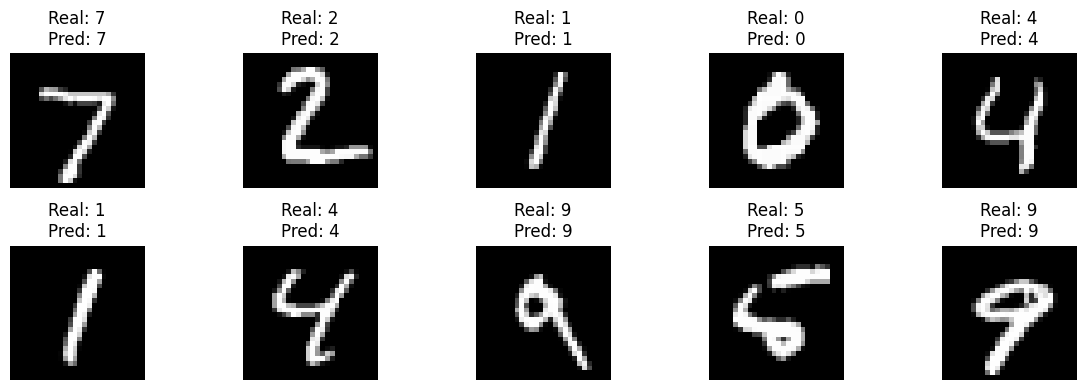

In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.datasets import mnist
import time
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar datos
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# 2. Preprocesamiento
x_train = x_train.reshape(-1, 28*28).astype("float32") / 255
x_test = x_test.reshape(-1, 28*28).astype("float32") / 255

# 3. Definición del modelo
model = Sequential([
    Dense(512, activation='relu'),
    Dense(10, activation='softmax')
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 4. Entrenamiento con temporizador
start = time.time()
model.fit(x_train, y_train, epochs=5, batch_size=128, verbose=1)
end = time.time()
print(f"⏱ Tiempo total de entrenamiento: {end - start:.2f} segundos")

# 5. Evaluación del modelo
loss, accuracy = model.evaluate(x_test, y_test)
print(f"✅ Precisión en test: {accuracy:.4f}")

# 6. Visualización de predicciones
predictions = model.predict(x_test[:10])
predicted_labels = np.argmax(predictions, axis=1)

# 7. Mostrar imágenes con predicciones
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"Real: {y_test[i]}\nPred: {predicted_labels[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.8707 - loss: 0.4626
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9648 - loss: 0.1199
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9792 - loss: 0.0711
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9848 - loss: 0.0511
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9904 - loss: 0.0352
⏱ Tiempo total de entrenamiento: 30.95 segundos
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9779 - loss: 0.0759
✅ Precisión en test: 0.9811
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


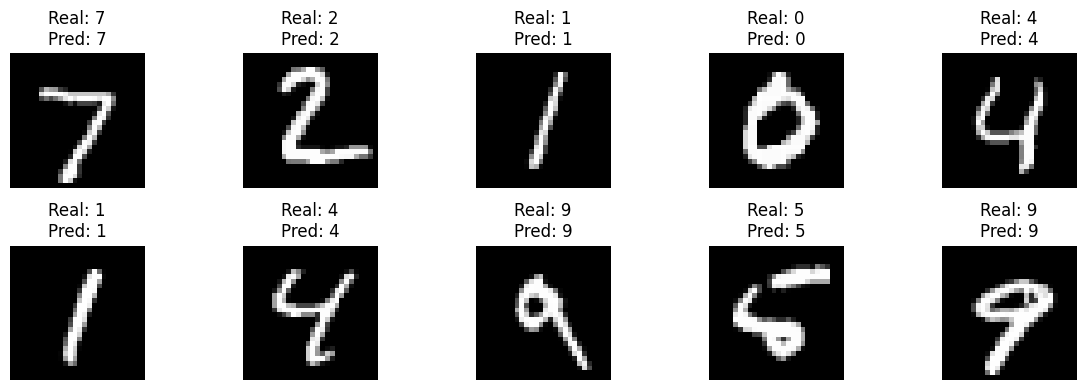

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.datasets import mnist
import time
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar datos
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# 2. Preprocesamiento
x_train = x_train.reshape(-1, 28*28).astype("float32") / 255
x_test = x_test.reshape(-1, 28*28).astype("float32") / 255

# 3. Definición del modelo
model = Sequential([
    Dense(512, activation='relu'),
    Dense(10, activation='softmax')
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 4. Entrenamiento con temporizador
start = time.time()
model.fit(x_train, y_train, epochs=5, batch_size=128, verbose=1)
end = time.time()
print(f"⏱ Tiempo total de entrenamiento: {end - start:.2f} segundos")

# 5. Evaluación del modelo
loss, accuracy = model.evaluate(x_test, y_test)
print(f"✅ Precisión en test: {accuracy:.4f}")

# 6. Visualización de predicciones
predictions = model.predict(x_test[:10])
predicted_labels = np.argmax(predictions, axis=1)

# 7. Mostrar imágenes con predicciones
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"Real: {y_test[i]}\nPred: {predicted_labels[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 34s 90ms/step - accuracy: 0.3429 - loss: 1.8544 - val_accuracy: 0.5214 - val_loss: 1.3706
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 31s 88ms/step - accuracy: 0.5430 - loss: 1.3163 - val_accuracy: 0.5510 - val_loss: 1.2599
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 43s 92ms/step - accuracy: 0.6002 - loss: 1.1493 - val_accuracy: 0.5942 - val_loss: 1.1532
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 40s 88ms/step - accuracy: 0.6250 - loss: 1.0797 - val_accuracy: 0.6180 - val_loss: 1.1027
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 40s 86ms/step - accuracy: 0.6493 - loss: 1.0104 - val_accuracy: 0.6366 - val_loss: 1.0598
Epoch 6/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 40s 84ms/step - accuracy: 0.6726 - loss: 0.9419 - val_accuracy: 0.6280 - val_loss: 1.0515
Epoch 7/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 44s 93ms/step - accuracy: 0.6829 - loss: 0.9119 - val_accuracy: 0.6590 - val_loss: 1.0058
Epoch 8/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 30s 85ms/step - accuracy: 0.7036 - loss: 0.8558 - 

/tmp/ipython-input-4-3829198079.py:44: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(f"Real: {class_names[int(y_test[i])]}\nPred: {class_names[pred_labels[i]]}")


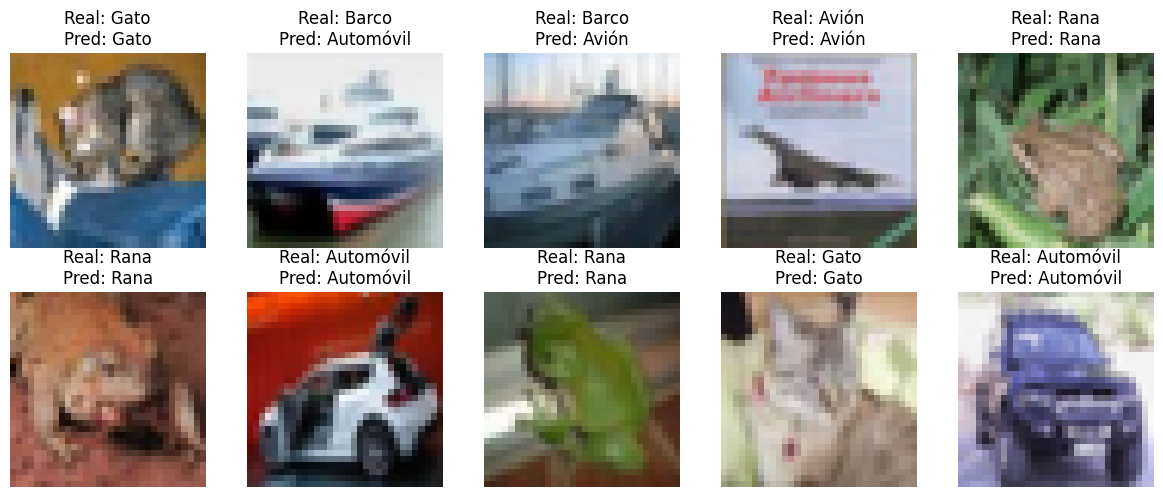

In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.datasets import cifar10
import numpy as np
import matplotlib.pyplot as plt
import time

# 1. Cargar datos
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

# 2. Definir modelo CNN
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(120, activation='relu'),
    Dense(10, activation='softmax')
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 3. Entrenamiento y tiempo
start = time.time()
history = model.fit(x_train, y_train, epochs=10, batch_size=128, validation_split=0.1, verbose=1)
end = time.time()
print(f"⏱ Tiempo total de entrenamiento: {end - start:.2f} segundos")

# 4. Evaluación
loss, acc = model.evaluate(x_test, y_test)
print(f"✅ Precisión en test: {acc:.4f}")

# 5. Diccionario de clases
class_names = ['Avión', 'Automóvil', 'Pájaro', 'Gato', 'Ciervo', 'Perro', 'Rana', 'Caballo', 'Barco', 'Camión']

# 6. Predicciones y visualización
preds = model.predict(x_test[:10])
pred_labels = np.argmax(preds, axis=1)

plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[i])
    plt.title(f"Real: {class_names[int(y_test[i])]}\nPred: {class_names[pred_labels[i]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()


In [6]:
from transformers import pipeline
import torch
import time

# Elegir dispositivo
device = 0 if torch.cuda.is_available() else -1

# Cargar pipeline
classifier = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english", device=device)

# Texto de ejemplo
text = "I love using transformers with GPU acceleration!"

# Medir tiempo de inferencia
start = time.time()
result = classifier(text)
end = time.time()

print("Resultado:", result)
print(f"⏱ Tiempo de inferencia: {end - start:.4f} segundos")


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Device set to use cuda:0


Resultado: [{'label': 'POSITIVE', 'score': 0.9984042048454285}]
⏱ Tiempo de inferencia: 0.3592 segundos


CPU

In [ ]:
from transformers import pipeline
import torch
import time

# Elegir dispositivo
device = 0 if torch.cuda.is_available() else -1

# Cargar pipeline
classifier = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english", device=device)

# Texto de ejemplo
text = "I love using transformers with GPU acceleration!"

# Medir tiempo de inferencia
start = time.time()
result = classifier(text)
end = time.time()

print("Resultado:", result)
print(f"⏱ Tiempo de inferencia: {end - start:.4f} segundos")

In [9]:
from transformers import AutoImageProcessor, AutoModelForImageClassification
from PIL import Image
import torch
import time
import requests

# Cargar imagen de internet
url = "https://huggingface.co/datasets/mishig/sample_images/resolve/main/tiger.jpg"
image = Image.open(requests.get(url, stream=True).raw).convert("RGB")

# Cargar modelo y procesador
processor = AutoImageProcessor.from_pretrained("google/vit-base-patch16-224")
model = AutoModelForImageClassification.from_pretrained("google/vit-base-patch16-224")

# Preparar imagen
inputs = processor(images=image, return_tensors="pt")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
inputs = {k: v.to(device) for k, v in inputs.items()}

# Medir tiempo de inferencia
start = time.time()
with torch.no_grad():
    outputs = model(**inputs)
end = time.time()

# Predicción
logits = outputs.logits
predicted = logits.argmax(-1).item()
label = model.config.id2label[predicted]

print("Etiqueta predicha:", label)
print(f"⏱ Tiempo de inferencia: {end - start:.4f} segundos")


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Etiqueta predicha: tiger, Panthera tigris
⏱ Tiempo de inferencia: 0.8238 segundos


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


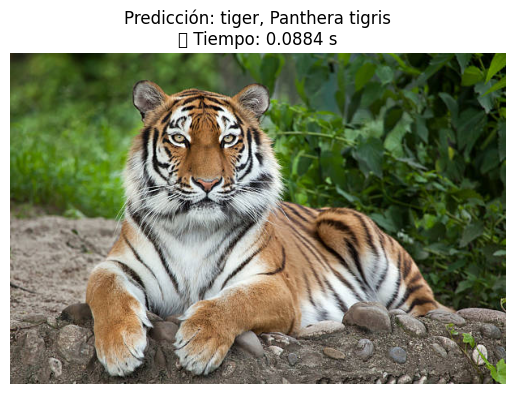

In [7]:
from transformers import AutoImageProcessor, AutoModelForImageClassification
from PIL import Image
import torch
import time
import requests
import matplotlib.pyplot as plt

# Cargar imagen de internet
url = "https://huggingface.co/datasets/mishig/sample_images/resolve/main/tiger.jpg"
image = Image.open(requests.get(url, stream=True).raw).convert("RGB")

# Cargar modelo y procesador
processor = AutoImageProcessor.from_pretrained("google/vit-base-patch16-224")
model = AutoModelForImageClassification.from_pretrained("google/vit-base-patch16-224")

# Preparar imagen
inputs = processor(images=image, return_tensors="pt")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
inputs = {k: v.to(device) for k, v in inputs.items()}

# Medir tiempo de inferencia
start = time.time()
with torch.no_grad():
    outputs = model(**inputs)
end = time.time()

# Predicción
logits = outputs.logits
predicted = logits.argmax(-1).item()
label = model.config.id2label[predicted]
inference_time = end - start

# Mostrar imagen y predicción
plt.imshow(image)
plt.axis('off')
plt.title(f"Predicción: {label}\n⏱ Tiempo: {inference_time:.4f} s", fontsize=12)
plt.show()


CPU

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


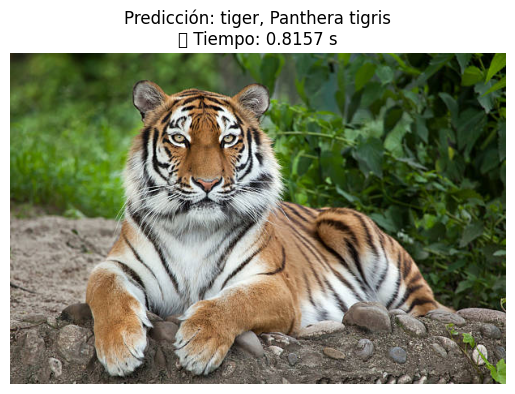

In [2]:
from transformers import AutoImageProcessor, AutoModelForImageClassification
from PIL import Image
import torch
import time
import requests
import matplotlib.pyplot as plt

# Cargar imagen de internet
url = "https://huggingface.co/datasets/mishig/sample_images/resolve/main/tiger.jpg"
image = Image.open(requests.get(url, stream=True).raw).convert("RGB")

# Cargar modelo y procesador
processor = AutoImageProcessor.from_pretrained("google/vit-base-patch16-224")
model = AutoModelForImageClassification.from_pretrained("google/vit-base-patch16-224")

# Preparar imagen
inputs = processor(images=image, return_tensors="pt")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
inputs = {k: v.to(device) for k, v in inputs.items()}

# Medir tiempo de inferencia
start = time.time()
with torch.no_grad():
    outputs = model(**inputs)
end = time.time()

# Predicción
logits = outputs.logits
predicted = logits.argmax(-1).item()
label = model.config.id2label[predicted]
inference_time = end - start

# Mostrar imagen y predicción
plt.imshow(image)
plt.axis('off')
plt.title(f"Predicción: {label}\n⏱ Tiempo: {inference_time:.4f} s", fontsize=12)
plt.show()
